# Класифікація зображень і базова згорткова мережа

## Бізнес-контекст
Компанія VisionScan AI розробляє систему автоматичного розпізнавання рукописних цифр для обробки банківських документів.
Ваше завдання — створити першу версію моделі, яка класифікує цифри 0-9 за зображеннями, використовуючи PyTorch.

https://mljourney.com/loading-the-mnist-dataset-in-pytorch-comprehensive-guide/

## Завдання 1
Підготуйте дані.
- Використовуйте датасет MNIST із torchvision.datasets.
- Завантажте навчальну і тестову вибірки.
- Перетворіть зображення в тензори та нормалізуйте їх.
- Створіть DataLoader із батчем розміром 64.

In [1]:
import torch
from torchvision import datasets, transforms

# Перетворіть зображення в тензори та нормалізуйте їх.
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Завантажте навчальну і тестову вибірки.
train_dataset = datasets.MNIST(root='data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='data', train=False, download=True, transform=transform)

# Data will be uploaded to ./data/MNIST/raw 

In [2]:
# Створіть DataLoader із батчем розміром 64.
from torch.utils.data import DataLoader

batch_size = 64

train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

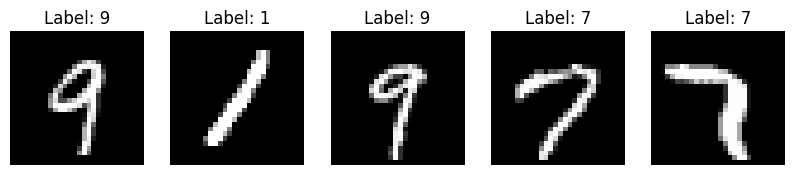

In [3]:
import matplotlib.pyplot as plt

# Display a few images with their labels
data_iter = iter(train_loader)
images, labels = next(data_iter)

plt.figure(figsize=(10, 2))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(images[i].squeeze(), cmap='gray')
    plt.title(f'Label: {labels[i]}')
    plt.axis('off')
plt.show()

## Завдання 2
Побудуйте просту згорткову нейронну мережу.
Використовуйте шари:
- Conv2d(1, 16, kernel_size=3);
- ReLU();
- MaxPool2d(2);
- Flatten();
- Linear(16 * 13 * 13, 10).

Функція втрат — CrossEntropyLoss,

оптимізатор — Adam(lr=0.001).

Навчіть модель 10 епох.

In [4]:
#  Define the Neural Network
import torch.nn as nn
import torch.optim as optim

class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        # Conv2d: input_channels=1 (e.g., grayscale image), output_channels=16, kernel=3x3
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3)
        self.relu = nn.ReLU()
        # Max pooling layer: 2x2
        self.pool = nn.MaxPool2d(kernel_size=2)
        # Fully connected layer: input features = 16 * 13 * 13, output = 10 classes
        self.fc1 = nn.Linear(16 * 13 * 13, 10)
    
    def forward(self, x):
        # Conv -> ReLU -> Pool
        x = self.pool(self.relu(self.conv1(x)))        
        # Flatten for the fully connected layer
        x = torch.flatten(x, 1)  # flatten all dimensions except batch        
        # Fully connected output
        x = self.fc1(x)
        return x

model = SimpleNN()


# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 10

## Завдання 3
Відстежуйте та візуалізуйте процес навчання.
- Виведіть втрати за епохами.
- Побудуйте графік залежності loss від епох.
- Збережіть модель у файл mnist_cnn.pth

In [5]:
losses = {}
# Training loop (rather slow)
for epoch in range(epochs):
    running_loss = 0.0
    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    losses[epoch + 1] = {running_loss / len(train_loader)}
    print(f'Epoch {epoch + 1}, Loss: {losses[epoch + 1]}')

Epoch 1, Loss: {0.24015683083455447}
Epoch 2, Loss: {0.08588284078582342}
Epoch 3, Loss: {0.06411918876732368}
Epoch 4, Loss: {0.05447994735040295}
Epoch 5, Loss: {0.04793731703734232}
Epoch 6, Loss: {0.04143970500873173}
Epoch 7, Loss: {0.0375636889341611}
Epoch 8, Loss: {0.03392922481063253}
Epoch 9, Loss: {0.030146722447810703}
Epoch 10, Loss: {0.02778525618698025}


In [6]:
[float(list(v)[0]) for k, v in losses.items()]

[0.24015683083455447,
 0.08588284078582342,
 0.06411918876732368,
 0.05447994735040295,
 0.04793731703734232,
 0.04143970500873173,
 0.0375636889341611,
 0.03392922481063253,
 0.030146722447810703,
 0.02778525618698025]

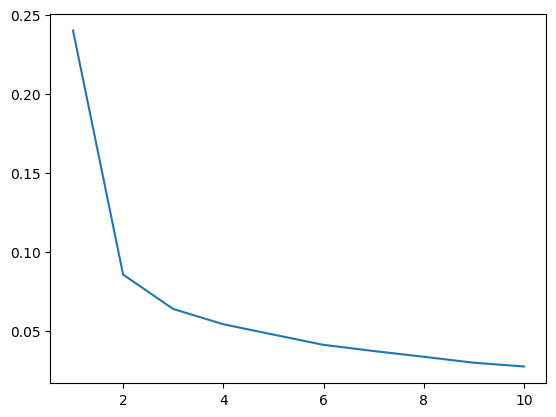

In [7]:
# Побудуйте графік залежності loss від епох.
fig, ax = plt.subplots()
ax.plot(losses.keys(), [float(list(v)[0]) for k, v in losses.items()])
plt.show()

In [8]:
# Збережіть модель у файл mnist_cnn.pth
torch.save(model.state_dict(), 'mnist_cnn.pth')

## Завдання 4
Перевірте точність моделі на тестовій вибірці та оформіть результати:
|Метрика|Значення|
|-|-|
|Accuracy|...|
|Loss|...|




In [9]:
# Evaluate the model
correct = 0
total = 0
mis = []
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        for i in range(len(labels)):
        if predicted[i] != labels[i] :
            mis.append({
                'label': labels[i],
                'predicted': predicted[i],
                'image': images[i]
            })

accuracy = 100 * correct / total
print(f'Accuracy on test set: {accuracy:.2f}%')

Accuracy on test set: 98.04%


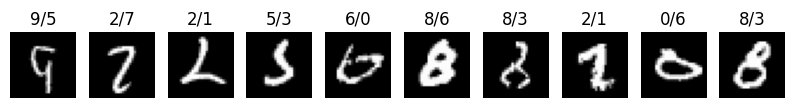

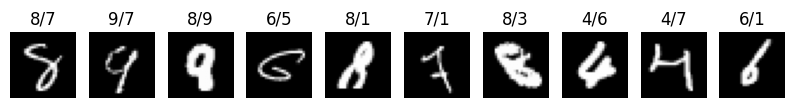

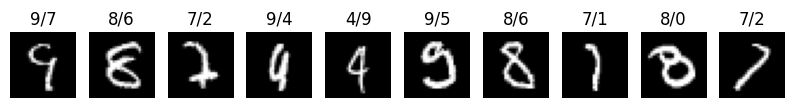

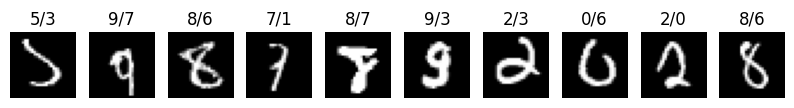

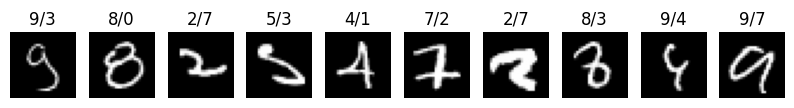

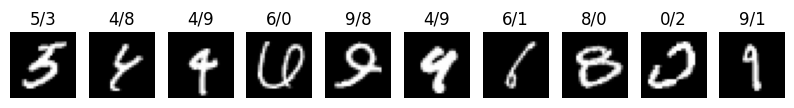

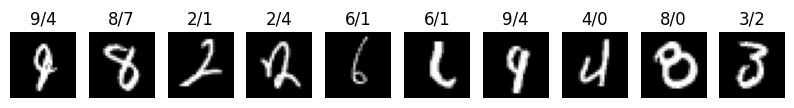

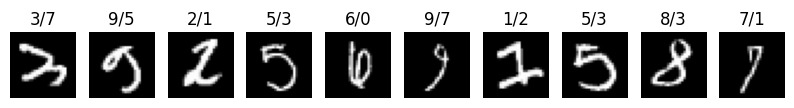

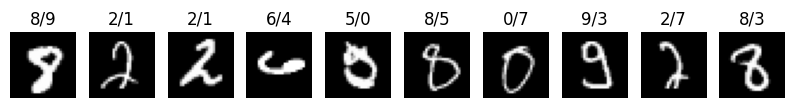

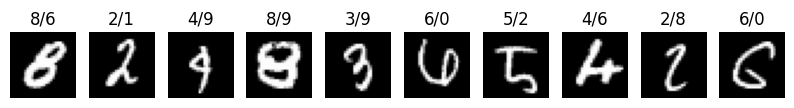

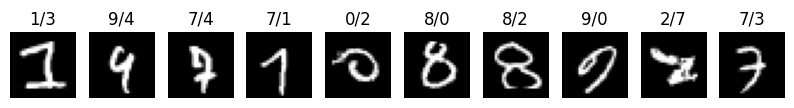

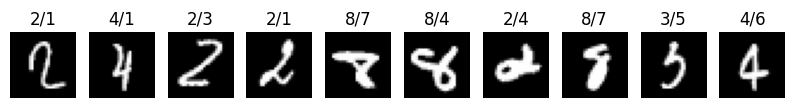

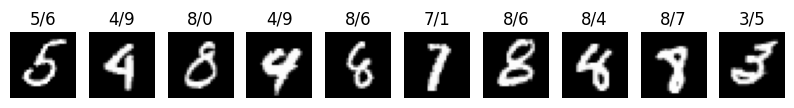

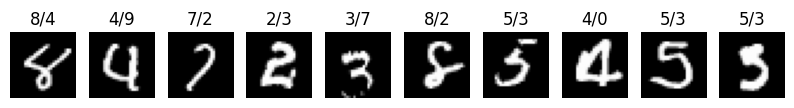

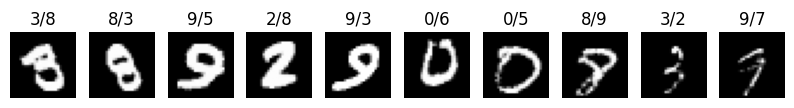

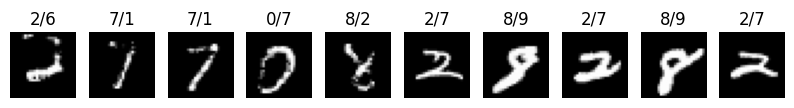

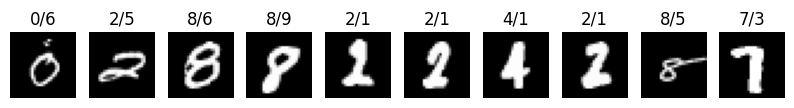

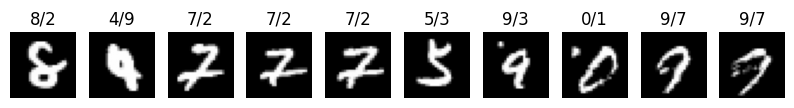

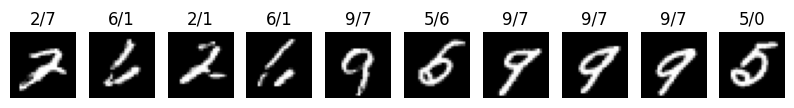

In [19]:
for m in range(len(mis) // 10) :
    plt.figure(figsize=(10, 2))
    for i in range(10):
        plt.subplot(1, 10, i+1)
        plt.imshow(mis[10*m+i]['image'].squeeze(), cmap='gray')
        plt.title(f'{mis[10*m+i]['label']}/{mis[10*m+i]['predicted']}')
        plt.axis('off')
    plt.show()

In [16]:
len(mis)

196